<Figure size 1200x800 with 0 Axes>

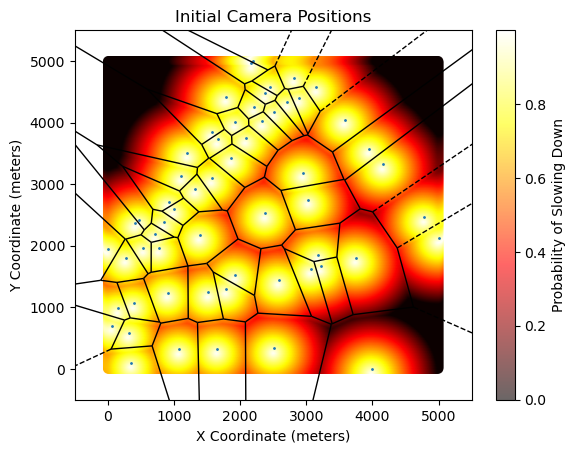

Initial Average Coverage Probability: 0.6241703324227846
Initializing population...
Generation 1/3
Completed generation 1.
Generation 2/3
Completed generation 2.
Generation 3/3
Completed generation 3.
Best Individual Fitness: 0.6700438250055825
Initializing population...
Generation 1/3
Completed generation 1.
Generation 2/3
Completed generation 2.
Generation 3/3
Completed generation 3.
Best Individual Fitness: 0.679690596075856
Initializing population...
Generation 1/3
Completed generation 1.
Generation 2/3
Completed generation 2.
Generation 3/3
Completed generation 3.
Best Individual Fitness: 0.6768659233664974
Initializing population...
Generation 1/3
Completed generation 1.
Generation 2/3
Completed generation 2.
Generation 3/3
Completed generation 3.
Best Individual Fitness: 0.6798508800782377
Initializing population...
Generation 1/3
Completed generation 1.
Generation 2/3
Completed generation 2.
Generation 3/3
Completed generation 3.
Best Individual Fitness: 0.6718902589368348
Init

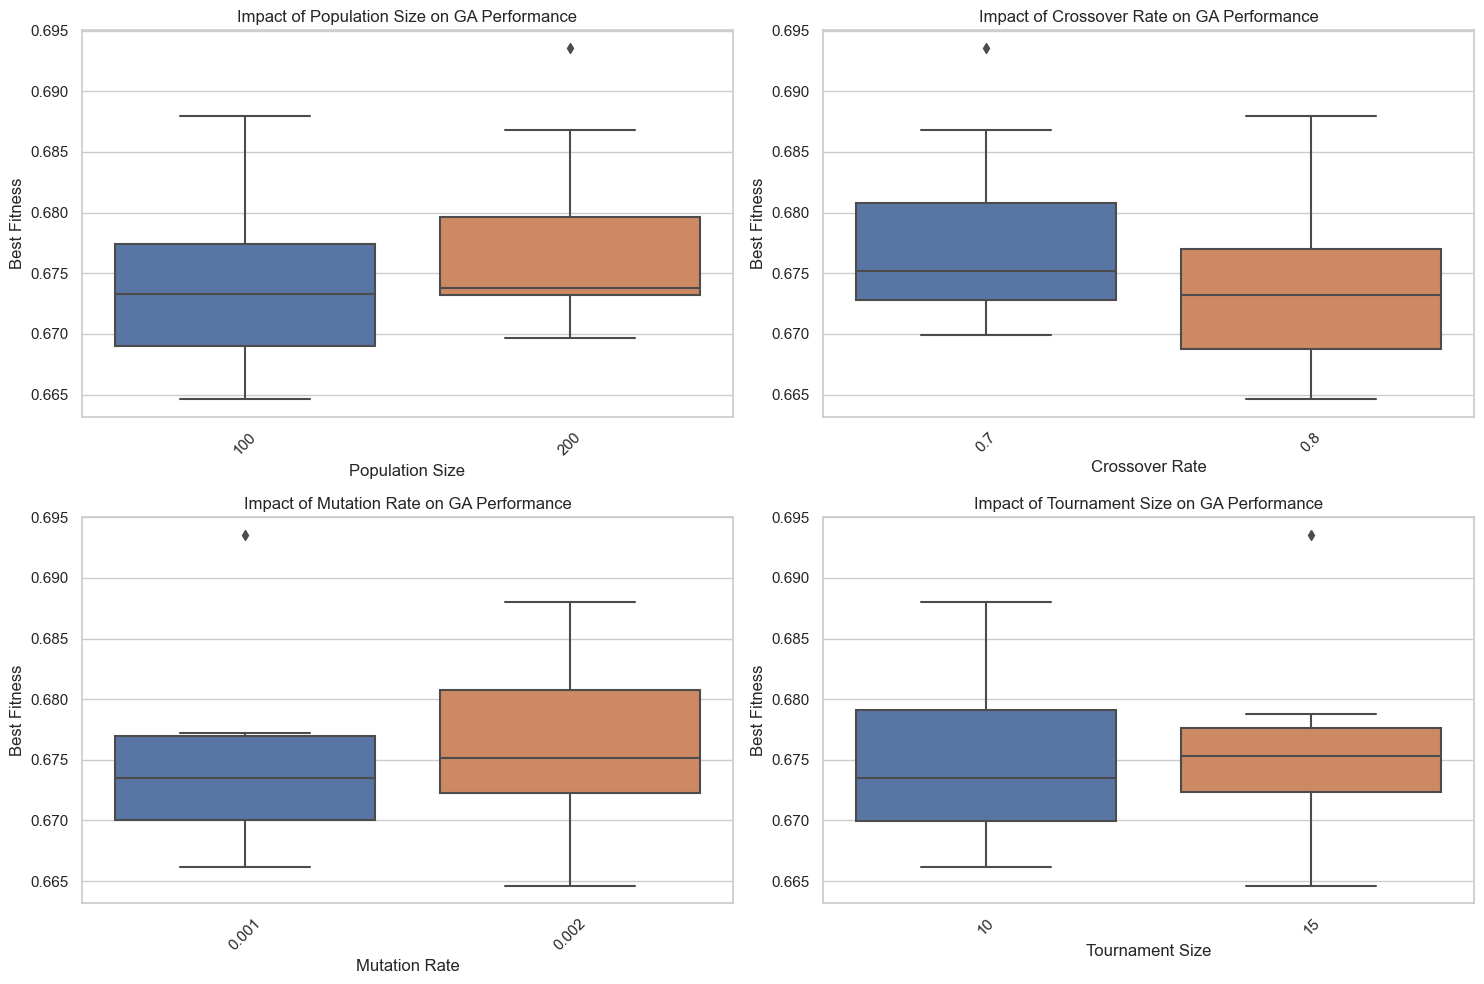

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import random
import time
import seaborn as sns
from itertools import product  # Make sure to import 'product' for parameter_sets

# Record the start time
start_time = time.time()


# Load the crash data
crash_data_df = pd.read_csv('/Users/sebi/Documents/Datos Tesis MIIIO/Puntos_Críticos_Stgo_2021.csv')  # Replace with your file path
provi_df = crash_data_df[crash_data_df['COMUNA'] == 'PROVIDENCIA']  # Filter for Providencia
crash_points = provi_df[['X', 'Y']].values  # Extracting the X and Y coordinates
siniestros = provi_df['Siniestros'].values
min_distance = 250
early_stopping_rounds = 8  # Adjust as necessary
tournament_size = 10  # Number of individuals participating in each tournament selection


# Define the target area size
area_size = [5000, 5000]  # in meters, adjust as needed
scaler = MinMaxScaler(feature_range=(0, max(area_size)))
scaled_crash_points = scaler.fit_transform(crash_points)  # Fit and transform the crash points
probability_threshold = 0.7  # Probability threshold for coverage

def is_inside_triangle(pt, v1, v2, v3):
    """
    Check if point pt (x,y) is inside the triangle defined by points
    v1, v2, and v3 using barycentric coordinates.
    """
    def sign(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    b1 = sign(pt, v1, v2) < 0.0
    b2 = sign(pt, v2, v3) < 0.0
    b3 = sign(pt, v3, v1) < 0.0

    return ((b1 == b2) and (b2 == b3))

# Triangle vertices
v1 = (0, 3000)
v2 = (0, 5000)
v3 = (2000, 5000)


# Function to calculate the probability of slowing down based on distance
def probability_of_slowing(dist):
    # Linear function parameters as solved previously
    a = -1/1000
    b = 1
    probability = a * dist + b
    # Ensure the probability is never negative, applied to each element of the array
    probability = np.maximum(probability, 0)
    return probability

# Create a grid of points for the heatmap
x = np.linspace(0, area_size[0], 500)
y = np.linspace(0, area_size[1], 500)
xx, yy = np.meshgrid(x, y)
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Initialize camera positions with scaled crash points
camera_positions = scaled_crash_points

def calculate_voronoi_coverage(grid_points, camera_positions, return_individual=False):
    vor = Voronoi(camera_positions)
    voronoi_coverage = []
    individual_coverages = []  # For storing individual cell coverage probabilities

    for point_index, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if region != [] and -1 not in region:
            vertexes = vor.vertices[region]
            mask = np.all(np.logical_and(vertexes >= 0, vertexes <= area_size), axis=1)
            if np.any(mask):
                cell_points = grid_points[np.all(np.logical_and(grid_points >= vertexes.min(axis=0), grid_points <= vertexes.max(axis=0)), axis=1)]
                if len(cell_points) > 0:  # Ensure cell_points is not empty
                    cell_distances = pairwise_distances(cell_points, [camera_positions[point_index]])
                    cell_probabilities = probability_of_slowing(np.min(cell_distances, axis=1))
                    if len(cell_probabilities) > 0:  # Ensure cell_probabilities is not empty
                        voronoi_coverage.append(np.mean(cell_probabilities))
                        individual_coverages.append(cell_probabilities)  # Store probabilities for each cell

    # Safely calculate the mean of voronoi_coverage
    average_coverage = np.mean(voronoi_coverage) if len(voronoi_coverage) > 0 else 0

    if return_individual:
        return average_coverage, individual_coverages
    else:
        return average_coverage



# Function for plotting Voronoi diagrams
def plot_voronoi(camera_positions, probabilities, title):
    plt.figure(figsize=(12, 8))
    vor = Voronoi(camera_positions)
    voronoi_plot_2d(vor, show_vertices=False, point_size=2)
    plt.scatter(xx, yy, c=probabilities, cmap='hot', alpha=0.6)
    plt.colorbar(label='Probability of Slowing Down')
    plt.title(title)
    plt.xlabel('X Coordinate (meters)')
    plt.ylabel('Y Coordinate (meters)')
    plt.show()


# Initial distances and probabilities
distances = pairwise_distances(grid_points, camera_positions)
min_distances = np.min(distances, axis=1)
probabilities = probability_of_slowing(min_distances)    
plot_voronoi(camera_positions, probabilities, 'Initial Camera Positions')
initial_avg_probability = calculate_voronoi_coverage(grid_points, camera_positions)
print(f"Initial Average Coverage Probability: {initial_avg_probability}")

# Fitness Function
def fitness_function(individual, grid_points):
    return calculate_voronoi_coverage(grid_points, individual)

# Selection - Tournament Selection
def select_parents(population, fitness, num_parents, tournament_size):
    # Adjusted implementation to use tournament_size
    parents = []
    for _ in range(num_parents):
        tournament = np.random.choice(len(population), size=tournament_size, replace=False)
        fittest_individual = tournament[np.argmax(fitness[tournament])]
        parents.append(population[fittest_individual])
    return parents


# Crossover - Uniform Crossover
def crossover(parents, crossover_rate):
    offspring = []
    for _ in range(int(len(parents)/2)):
        parent1, parent2 = random.sample(parents, 2)
        child1, child2 = parent1.copy(), parent2.copy()
        for i in range(len(parent1)):
            if np.random.rand() < crossover_rate:
                child1[i], child2[i] = child2[i], child1[i]
        offspring.extend([child1, child2])
    return offspring

# Function to enforce minimum distance between cameras after mutation and crossover
def enforce_minimum_distance(cameras, min_distance):
    for i in range(len(cameras)):
        for j in range(i+1, len(cameras)):
            while np.linalg.norm(cameras[i] - cameras[j]) < min_distance or is_inside_triangle(cameras[j], v1, v2, v3):
                cameras[j] = np.random.uniform(0, max(area_size), 2)
                while is_inside_triangle(cameras[j], v1, v2, v3):
                    cameras[j] = np.random.uniform(0, max(area_size), 2)
    return cameras

#Crash Data Untouchable Cameras by accident numbers--------------------------------------------------------------------
fixed_cameras_mask = siniestros >= 7
fixed_cameras = scaled_crash_points[fixed_cameras_mask]

def initialize_population_with_fixed(pop_size, crash_points, fixed_cameras):
    population = []
    for _ in range(pop_size):
        variable_cameras = []
        while len(variable_cameras) < len(crash_points) - len(fixed_cameras):
            potential_point = crash_points[np.random.choice(crash_points.shape[0]), :]
            if not is_inside_triangle(potential_point, v1, v2, v3):
                variable_cameras.append(potential_point)
        variable_cameras = np.array(variable_cameras)
        individual = np.vstack((variable_cameras, fixed_cameras))
        np.random.shuffle(individual)
        population.append(individual)
    return population

# Modify the mutation function to avoid mutating fixed cameras
def mutation_with_fixed(offspring, mutation_rate, crash_points, area_size, fixed_cameras):
    for child in offspring:
        for i in range(len(child)):
            if np.random.rand() < mutation_rate and not np.any(np.all(child[i] == fixed_cameras, axis=1)):
                valid_point = False
                while not valid_point:
                    potential_point = crash_points[np.random.choice(crash_points.shape[0]), :]
                    if (0 <= potential_point[0] <= area_size[0] and
                        0 <= potential_point[1] <= area_size[1] and
                        not is_inside_triangle(potential_point, v1, v2, v3)):
                        valid_point = True
                child[i] = potential_point
    return offspring

# Simplified GA implementation with dynamic parameters
# Mutation, and evolution steps with added print statements for monitoring
def genetic_algorithm(crash_points, grid_points, num_generations, population_size, crossover_rate, mutation_rate, tournament_size, fixed_cameras, area_size):
    print("Initializing population...")
    population = initialize_population_with_fixed(population_size, crash_points, fixed_cameras)  # Placeholder for your population initialization function
    best_fitness = 0
    
    for generation in range(num_generations):
        print(f"Generation {generation + 1}/{num_generations}")
        
        # Calculate fitness for each individual in the population
        fitness = np.array([fitness_function(individual, grid_points) for individual in population])
        best_fitness_generation = np.max(fitness)
        if best_fitness_generation > best_fitness:
            best_fitness = best_fitness_generation
        
        # Selection
        parents = select_parents(population, fitness, int(population_size / 2), tournament_size)
        
        # Crossover
        offspring = crossover(parents, crossover_rate)
        
        # Mutation, corrected to pass area_size as a tuple/list
        offspring = mutation_with_fixed(offspring, mutation_rate, crash_points, area_size, fixed_cameras)
        
        # Enforce minimum distance after mutation (assuming your implementation)
        offspring = [enforce_minimum_distance(child, min_distance) for child in offspring]
        
        # Updating the population for the next generation
        population = parents + offspring
        print(f"Completed generation {generation + 1}.")

    # Identifying the best individual based on fitness
    best_index = np.argmax([fitness_function(ind, grid_points) for ind in population])
    best_individual = population[best_index]
    best_individual_fitness = fitness_function(best_individual, grid_points)
    print(f"Best Individual Fitness: {best_individual_fitness}")
    return best_individual, best_fitness
    
# Parameter tuning function
def tune_ga_parameters(crash_points, grid_points, fixed_cameras, parameter_sets):
    results = []
    for params in parameter_sets:
        population_size, crossover_rate, mutation_rate, tournament_size = params
        _, best_fitness = genetic_algorithm(crash_points, grid_points, 3, population_size, crossover_rate, mutation_rate, tournament_size, fixed_cameras, area_size)
        results.append((*params, best_fitness))
    
    results_df = pd.DataFrame(results, columns=['Population Size', 'Crossover Rate', 'Mutation Rate', 'Tournament Size', 'Best Fitness'])
    return results_df

def plot_parameter_impact(results_df):
    # Improve plot aesthetics using seaborn
    sns.set(style="whitegrid")

    # Define the parameters to plot
    parameters = ['Population Size', 'Crossover Rate', 'Mutation Rate', 'Tournament Size']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()  # Flatten the axes array for easy iteration
    
    for i, param in enumerate(parameters):
        # For each parameter, we create a boxplot of the GA performance across different values of that parameter
        sns.boxplot(x=param, y='Best Fitness', data=results_df, ax=axes[i])
        axes[i].set_title(f'Impact of {param} on GA Performance')
        axes[i].set_xlabel(param)
        axes[i].set_ylabel('Best Fitness')
        axes[i].tick_params(axis='x', rotation=45)  # Rotate labels to improve readability
    
    plt.tight_layout()
    plt.show()


# Define parameter ranges
population_sizes = [100, 200]
crossover_rates = [0.7, 0.8]
mutation_rates = [0.001, 0.002]
tournament_sizes = [10, 15]

parameter_sets = list(product(population_sizes, crossover_rates, mutation_rates, tournament_sizes))

# Example usage
results_df = tune_ga_parameters(scaled_crash_points, grid_points, fixed_cameras, parameter_sets)
plot_parameter_impact(results_df)


In [2]:
# Find the best parameters after tuning
best_parameters_row = results_df.loc[results_df['Best Fitness'].idxmax()]
print("\nBest Parameters Found:")
print(best_parameters_row)


Best Parameters Found:
Population Size    200.000000
Crossover Rate       0.700000
Mutation Rate        0.001000
Tournament Size     15.000000
Best Fitness         0.693574
Name: 9, dtype: float64
